# Бонусное домашнее задание

## Part 0

В данном домашнем задании вам предстоит реализовать СLIP -- self-supervision модель которая выучивает зависимости между картинками и текстов в едином векторном пространстве. Для выполнения этого домашнего задания вам понадобится GPU и несколько дополнительных библиотек. Автор рекомендует делать все исключительно в Kaggle. 


[Ссылка на датасет](https://www.kaggle.com/datasets/keenwarrior/small-flicker-data-for-image-captioning)

[Ссылка на статью](https://openai.com/research/clip)

Задания в ноутбуке будут во многом опираться на статью, поэтому рекомендуется ее прочитать перед выполнением.

In [6]:
!pip install timm
!pip install transformers

In [7]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import os
import glob
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
import pandas as pd
import timm
PATH_TO_IMAGES = '/kaggle/input/datasets/keenwarrior/small-flicker-data-for-image-captioning/flickr1k/images'

## Part 1 (8 баллов)

Для начала нам нужно реализовать составляющие модели: Кодировщик картинок, текста и проектор на какое-то маломерное пространство. В папке с заданием есть соответствующие файлы, заполните пропуски в них опираясь на docstring-и.

Разбалловка следующая: 

Правильно реализованные кодировщики: 2 балла.

Правильно реализованный проектор: 2 балла.

Правильно реализованный класс СLIP: 4 балла.

In [8]:
import sys

module_path = '/kaggle/input/datasets/nikitanazarov1504/clip-pyfiles' 

if module_path not in sys.path:
    sys.path.append(module_path)

In [9]:
from CLIPDataset import CLIPDataset
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer
from ImageEncoder import ImageEncoder
from ProjectionHead import ProjectionHead
from TextEncoder import TextEncoder

In [10]:
import torch.nn.functional as F

In [12]:
class CLIP(nn.Module):
    def __init__(self, image_embedding=2048, text_embedding=768, temp =1.0):
        super().__init__()
        self.image_encoder = ImageEncoder() #TODO
        self.text_encoder = TextEncoder() #TODO
        self.image_projections = ProjectionHead(embedding_dim=image_embedding) #TODO
        self.text_projections = ProjectionHead(embedding_dim=text_embedding) #TODO
        self.temp = temp
    def forward(self, batch):
        """
        :batch: dict of images and text
        Here is what you should do:
        1) extract image and text features from batch
        2) project features into projection space (small latent space)
        3) compute cosine similarity with temperature this will be your logits
        4) compute "true" logits (eg. cosine similarity between images and images, text and text)
        5) create targets by averaging similarities from step above (do not forget about temperature)
        6) compute mean loss (see paper)
        7) return loss

        Overall: read paper.
        
        """
        #TODO: 
        image_features = self.image_encoder(batch['image'])
        text_features = self.text_encoder(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        image_embeds = self.image_projections(image_features)
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = self.text_projections(text_features)
        text_embeds = F.normalize(text_embeds, dim=-1)
        logits = (image_embeds @ text_embeds.T) / self.temp
        image_similars = image_embeds @ image_embeds.T
        text_similars = text_embeds @ text_embeds.T
        targets = F.softmax((image_similars + text_similars) / (2 * self.temp), dim=-1)
        loss_i = CE(logits, targets)
        loss_t = CE(logits.T, targets.T)
        loss = (loss_i + loss_t) / 2
        return loss.mean()
    

def CE(preds, targets):
    log_softmax = nn.LogSoftmax(dim=-1)
    loss = (-targets * log_softmax(preds)).sum(1)
    return loss   

# Part 2. (0 Баллов)

Здесь вам нужно вписать правильный путь до csv файла на своей машине и запустить код.

In [13]:
def make_train_valid_dfs():
    dataframe = pd.read_csv(f"{'/kaggle/input/datasets/keenwarrior/small-flicker-data-for-image-captioning/flickr1k/captions.csv'}")
    dataframe["id"] = np.array(list(dataframe.index))
    max_id = dataframe["id"].max() + 1
    image_ids = np.arange(0, max_id)
    np.random.seed(42)
    valid_ids = np.random.choice(
        image_ids, size=int(0.2 * len(image_ids)), replace=False
    )
    train_ids = [id_ for id_ in image_ids if id_ not in valid_ids]
    train_dataframe = dataframe[dataframe["id"].isin(train_ids)].reset_index(drop=True)
    valid_dataframe = dataframe[dataframe["id"].isin(valid_ids)].reset_index(drop=True)
    return train_dataframe, valid_dataframe

In [14]:
def build_loaders(dataframe, tokenizer, mode):
    dataset = CLIPDataset(
        '/kaggle/input/datasets/keenwarrior/small-flicker-data-for-image-captioning/flickr1k/images', #добавил, тк в шаблоне требуется параметр image_path
        dataframe["image"].values,
        dataframe["caption"].values,
        tokenizer=tokenizer
    )
    dataloader = DataLoader(
        dataset,
        batch_size=32,
        num_workers=1,
        shuffle=True if mode == "train" else False,
    )
    return dataloader, dataset

In [15]:
class AvgMeter:
    def __init__(self, name="CrossEntropyLoss"):
        self.name = name
        self.reset()

    def reset(self):
        self.avg, self.sum, self.count = [0] * 3

    def update(self, val, count=1):
        self.count += count
        self.sum += val * count
        self.avg = self.sum / self.count

    def __repr__(self):
        text = f"{self.name}: {self.avg:.4f}"
        return text
    
    def __format__(self, formatspec):
        text = f"{self.name}: {format(self.avg, formatspec)}"
        return text

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

In [16]:
def train(model, train_loader, optimizer, lr_scheduler, step):
    loss_meter = AvgMeter()
    for batch in tqdm(train_loader, desc="Training", total=len(train_loader)):
        batch = {key: value.to(device) for key, value in batch.items() if key != "caption"}
        loss = model(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step == "batch":
            lr_scheduler.step()
        loss_meter.update(loss.item(), batch["image"].shape[0])
    return loss_meter

@torch.no_grad()
def validate(model, validation_loader):
    loss_meter = AvgMeter()
    for batch in tqdm(validation_loader, desc="Validating", total=len(validation_loader)):
        batch = {key: value.to(device) for key, value in batch.items() if key != "caption"}
        loss = model(batch)
        loss_meter.update(loss.item(), batch["image"].shape[0])
    return loss_meter

## Part 3. (2 балла)

За вас написан минимальный код для обучения, если он запускается и модель учится, то за этот пункт вы получите 0.5 балла. Чтобы получить полный балл за задание вам нужно будет провести несколько экспериментов и поподбирать гиперпараметры. Можно начать со статьи.

In [17]:
import itertools
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCH = 10
def procedure():
    train_df, validation_df = make_train_valid_dfs()
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    train_loader, _ = build_loaders(train_df, tokenizer, mode="train")
    val_loader, _ = build_loaders(validation_df, tokenizer, mode="valid")
    model = CLIP().to(device)
    params = [{"params": model.image_encoder.parameters()}, 
              {"params" : model.text_encoder.parameters()},
              {"params" : itertools.chain(model.image_projections.parameters(),
                                          model.text_projections.parameters())}]
    optimizer = torch.optim.Adam(params)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.8)
    step="epoch"
    for epoch in range(EPOCH):
        print(f"Epoch: {epoch}. Train and Validation in progress...")
        model.train()
        train_loss = train(model, train_loader, optimizer, lr_scheduler, step)
        model.eval()
        val_loss = validate(model, val_loader)
        
        lr_scheduler.step(val_loss.avg)
        print(f"Epoch: {epoch},", end="\n")
        print(f"Train loss: {train_loss:0.3f}", end="\n")
        print(f"Validation loss: {val_loss:0.3f}")
    return model

In [18]:
model = procedure()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 8,
Train loss: CrossEntropyLoss: 3.285
Validation loss: CrossEntropyLoss: 3.267
Epoch: 9. Train and Validation in progress...


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 9,
Train loss: CrossEntropyLoss: 3.280
Validation loss: CrossEntropyLoss: 3.272


Это результаты baseline (Adam, lr для энкодеров и для проекций: 1e-3, temperature: 1, scheduler: ReduceLROnPlateau)

Теперь запустим 1 эксперимент (AdamW с weight_decay=0.2, lr для энкодеров: 1e-4, lr для декодеров: 1e-3, temperature: 1, scheduler: Cosine+Warmup (закодю его)):

In [19]:
import math

def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [20]:
train_df, validation_df = make_train_valid_dfs()
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
train_loader, _ = build_loaders(train_df, tokenizer, mode="train")
val_loader, _ = build_loaders(validation_df, tokenizer, mode="valid")
model_exp1 = CLIP().to(device)
params = [{"params": model_exp1.image_encoder.parameters(), "lr": 1e-4}, 
          {"params" : model_exp1.text_encoder.parameters(), "lr": 1e-4},
          {"params" : itertools.chain(model_exp1.image_projections.parameters(),
                                          model_exp1.text_projections.parameters()), "lr": 1e-3}]
optimizer = torch.optim.AdamW(params, weight_decay=0.2)
total_steps = EPOCH * len(train_loader)
warmup_steps = min(100, total_steps // 10)
lr_scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
hist_exp1 = []
for epoch in range(EPOCH):
    print(f"Epoch: {epoch}. Train and Validation in progress...")
    model_exp1.train()
    train_loss = train(model_exp1, train_loader, optimizer, lr_scheduler, step='batch')
    model_exp1.eval()
    val_loss = validate(model_exp1, val_loader)
    hist_exp1.append({'train': train_loss.avg, 'val': val_loss.avg})
    print(f"Epoch: {epoch},", end="\n")
    print(f"Train loss: {train_loss:0.3f}", end="\n")
    print(f"Validation loss: {val_loss:0.3f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch: 0. Train and Validation in progress...


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 8,
Train loss: CrossEntropyLoss: 3.278
Validation loss: CrossEntropyLoss: 3.266
Epoch: 9. Train and Validation in progress...


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 9,
Train loss: CrossEntropyLoss: 3.277
Validation loss: CrossEntropyLoss: 3.264


Получилось немного получше, чем в бейзлайне, где на треине лосс был 3.280, а на валидации 3.272

Теперь запустим 2 эксперимент (AdamW с weight_decay=0.2, lr для энкодеров: 1e-4, lr для декодеров: 1e-3 оставляем, а вот temperature: 0.07 теперь, scheduler: Cosine+Warmup)

In [21]:
train_df, validation_df = make_train_valid_dfs()
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
train_loader, _ = build_loaders(train_df, tokenizer, mode="train")
val_loader, _ = build_loaders(validation_df, tokenizer, mode="valid")
model_exp2 = CLIP(temp=0.07).to(device)
params = [{"params": model_exp2.image_encoder.parameters(), "lr": 1e-4}, 
          {"params" : model_exp2.text_encoder.parameters(), "lr": 1e-4},
          {"params" : itertools.chain(model_exp2.image_projections.parameters(),
                                          model_exp2.text_projections.parameters()), "lr": 1e-3}]
optimizer = torch.optim.AdamW(params, weight_decay=0.2)
total_steps = EPOCH * len(train_loader)
warmup_steps = min(100, total_steps // 10)
lr_scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
hist_exp2 = []
for epoch in range(EPOCH):
    print(f"Epoch: {epoch}. Train and Validation in progress...")
    model_exp2.train()
    train_loss = train(model_exp2, train_loader, optimizer, lr_scheduler, step='batch')
    model_exp2.eval()
    val_loss = validate(model_exp2, val_loader)
    hist_exp2.append({'train': train_loss.avg, 'val': val_loss.avg})
    print(f"Epoch: {epoch},", end="\n")
    print(f"Train loss: {train_loss:0.3f}", end="\n")
    print(f"Validation loss: {val_loss:0.3f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch: 0. Train and Validation in progress...


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 8,
Train loss: CrossEntropyLoss: 0.294
Validation loss: CrossEntropyLoss: 1.087
Epoch: 9. Train and Validation in progress...


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 9,
Train loss: CrossEntropyLoss: 0.267
Validation loss: CrossEntropyLoss: 1.090


Новая temp дала улучшения val loss примерно в 3 раза, но виден яркий overfitting, так лосс на треине намного меньше (0.267)

Теперь запустим 3 эксперимент (AdamW с weight_decay=0.2, lr для энкодеров: 1e-4, lr для декодеров: 1e-3 оставляем, а вот temperature: обучаемая теперь, scheduler: Cosine+Warmup). Для обучаемой температуры немного перепишу класс CLIP:

In [23]:
class CLIP(nn.Module):
    def __init__(self, image_embedding=2048, text_embedding=768, temp =1.0, learnable_temp=False):
        super().__init__()
        self.image_encoder = ImageEncoder() #TODO
        self.text_encoder = TextEncoder() #TODO
        self.image_projections = ProjectionHead(embedding_dim=image_embedding) #TODO
        self.text_projections = ProjectionHead(embedding_dim=text_embedding) #TODO
        self.temp = temp
        if learnable_temp:
            self.temp = nn.Parameter(torch.tensor(temp))
        else:
            self.temp = temp
    def forward(self, batch):
        """
        :batch: dict of images and text
        Here is what you should do:
        1) extract image and text features from batch
        2) project features into projection space (small latent space)
        3) compute cosine similarity with temperature this will be your logits
        4) compute "true" logits (eg. cosine similarity between images and images, text and text)
        5) create targets by averaging similarities from step above (do not forget about temperature)
        6) compute mean loss (see paper)
        7) return loss

        Overall: read paper.
        
        """
        #TODO: 
        image_features = self.image_encoder(batch['image'])
        text_features = self.text_encoder(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        image_embeds = self.image_projections(image_features)
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = self.text_projections(text_features)
        text_embeds = F.normalize(text_embeds, dim=-1)
        logits = (image_embeds @ text_embeds.T) / self.temp
        image_similars = image_embeds @ image_embeds.T
        text_similars = text_embeds @ text_embeds.T
        targets = F.softmax((image_similars + text_similars) / (2 * self.temp), dim=-1)
        loss_i = CE(logits, targets)
        loss_t = CE(logits.T, targets.T)
        loss = (loss_i + loss_t) / 2
        return loss.mean()
    

def CE(preds, targets):
    log_softmax = nn.LogSoftmax(dim=-1)
    loss = (-targets * log_softmax(preds)).sum(1)
    return loss   

In [24]:
train_df, validation_df = make_train_valid_dfs()
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
train_loader, _ = build_loaders(train_df, tokenizer, mode="train")
val_loader, _ = build_loaders(validation_df, tokenizer, mode="valid")
model_exp3 = CLIP(temp=0.07, learnable_temp=True).to(device)
params = [{"params": model_exp3.image_encoder.parameters(), "lr": 1e-4}, 
          {"params" : model_exp3.text_encoder.parameters(), "lr": 1e-4},
          {"params" : itertools.chain(model_exp3.image_projections.parameters(),
                                          model_exp3.text_projections.parameters()), "lr": 1e-3},
          {"params": [model_exp3.temp], "lr": 1e-3}]
optimizer = torch.optim.AdamW(params, weight_decay=0.2)
total_steps = EPOCH * len(train_loader)
warmup_steps = min(100, total_steps // 10)
lr_scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
hist_exp3 = []
for epoch in range(EPOCH):
    print(f"Epoch: {epoch}. Train and Validation in progress...")
    model_exp3.train()
    train_loss = train(model_exp3, train_loader, optimizer, lr_scheduler, step='batch')
    model_exp3.eval()
    val_loss = validate(model_exp3, val_loader)
    hist_exp3.append({'train': train_loss.avg, 'val': val_loss.avg})
    print(f"Epoch: {epoch},", end="\n")
    print(f"Train loss: {train_loss:0.3f}", end="\n")
    print(f"Validation loss: {val_loss:0.3f}")
    print(f'Temperature: {model_exp3.temp.item()}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch: 0. Train and Validation in progress...


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 8,
Train loss: CrossEntropyLoss: 0.234
Validation loss: CrossEntropyLoss: 1.319
Temperature: 0.028240177780389786
Epoch: 9. Train and Validation in progress...


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 9,
Train loss: CrossEntropyLoss: 0.222
Validation loss: CrossEntropyLoss: 1.318
Temperature: 0.028085783123970032


Здесь val loss больше, чем в предыдущем эксперименте, а на лосс на треине, наоборот, меньше, чем в предыдущем эксперименте - получается еще сильнее overfitting, чем в прошлом эксперименте

По температуре модель спустилась с 0.07 к примерно 0.028 (вероятно, в этом и заключается причина overfitting-а)

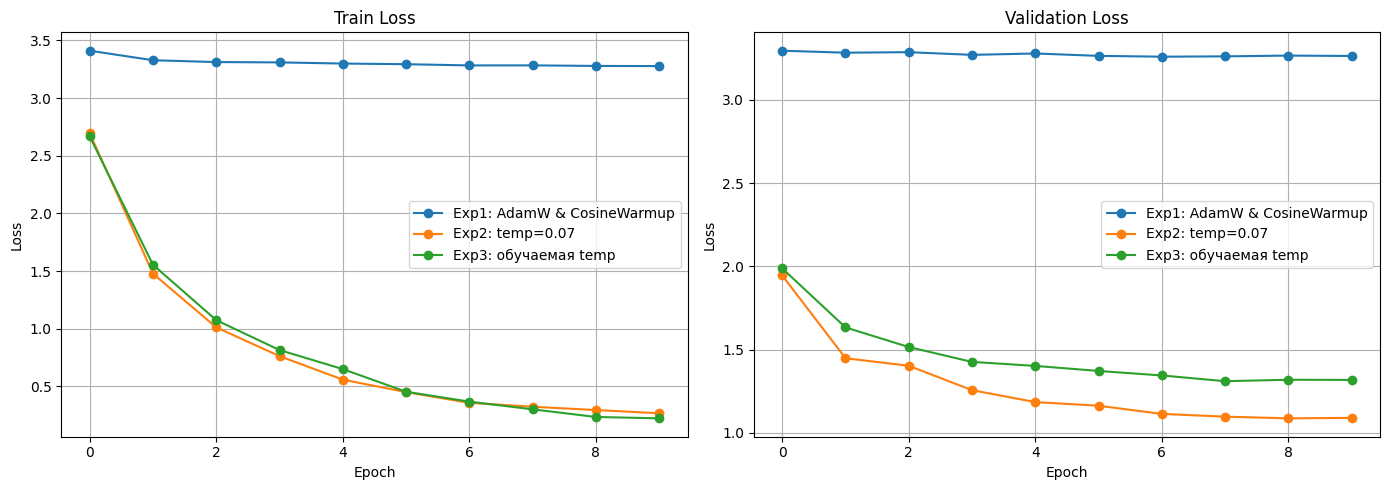

In [100]:
epochs = range(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, [h['train'] for h in hist_exp1], label='Exp1: AdamW & CosineWarmup', marker='o')
ax1.plot(epochs, [h['train'] for h in hist_exp2], label='Exp2: temp=0.07', marker='o')
ax1.plot(epochs, [h['train'] for h in hist_exp3], label='Exp3: обучаемая temp', marker='o')
ax1.set_title('Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, [h['val'] for h in hist_exp1], label='Exp1: AdamW & CosineWarmup', marker='o')
ax2.plot(epochs, [h['val'] for h in hist_exp2], label='Exp2: temp=0.07', marker='o')
ax2.plot(epochs, [h['val'] for h in hist_exp3], label='Exp3: обучаемая temp', marker='o')
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Part 4 (0 баллов)

Просто посмотрим на результаты.

In [26]:
@torch.inference_mode()
def get_image_embeddings(valid_df, model):
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    valid_loader, _ = build_loaders(valid_df, tokenizer, mode="valid")
    valid_image_embeddings = []
    for batch in tqdm(valid_loader, desc="Getting embeddings", total=len(valid_loader)):
        batch = {key: value.to(device) for key, value in batch.items() if key != "caption"}
        image_features = model.image_encoder(batch["image"]).to(device) #убрал permute
        image_embeddings = model.image_projections(image_features)
        valid_image_embeddings.append(image_embeddings)
    return torch.cat(valid_image_embeddings)

In [27]:
import matplotlib.pyplot as plt
@torch.inference_mode()
def find_match(model, image_embeddings, text, image_filenames, num_examples=4):
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    text_encoded = tokenizer([text])
    batch = {key : torch.tensor(value).to(device) for key, value in text_encoded.items()}
    
    text_features = model.text_encoder(batch["input_ids"], batch["attention_mask"])
    text_embeddings = model.text_projections(text_features)
    
    norm_image_embeddings = nn.functional.normalize(image_embeddings, p=2, dim=-1)
    norm_text_embeddings = nn.functional.normalize(text_embeddings, p=2, dim=-1)
    
    similarity = norm_text_embeddings @ norm_image_embeddings.T
    
    ans, ans_index = torch.topk(similarity.squeeze(0), num_examples * 5)
    match = [image_filenames[index] for index in ans_index[::5]]
    fig, ax = plt.subplots(int(num_examples/2), int(num_examples/2), figsize= (10, 10))
    for m, a in zip(match, ax.flatten()):
        image = Image.open(f"{PATH_TO_IMAGES}" + f"/{m}")
        image = image.convert("RGB")
        a.imshow(image)
        a.axis("off")
    plt.show()
    

In [66]:
_, valid_df = make_train_valid_dfs()
print(*valid_df["caption"].sample(10).tolist(), sep='\n')

A man with a shaved head is kissing another man on the cheek .
Two small dogs are chasing a ball .
A person in an orange helmet climbs up a sheer cliff face .
a black dog runs through a field .
A woman in a blue jacket rides a brown pony near water .
A woman with holding a young girl playing with bubbles at a picnic .
The young boy pedals quickly at a BMX race .
A sign asking for help with a man walking by eating .
A child with and adult hand .
A dog runs while holding an object in its mouth .


К СОЖАЛЕНИЮ, в энитаск не грузится ноут с картинками, поэтому очищу все ячейки с картинками для модели из 1 и 3 эксперимента (там правда то, о чем я пишу)

In [78]:
_, valid_df = make_train_valid_dfs()
image_embeddings = get_image_embeddings(valid_df, model)

Getting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
find_match(model, image_embeddings, "Two small dogs are chasing a ball", valid_df["image"].values)

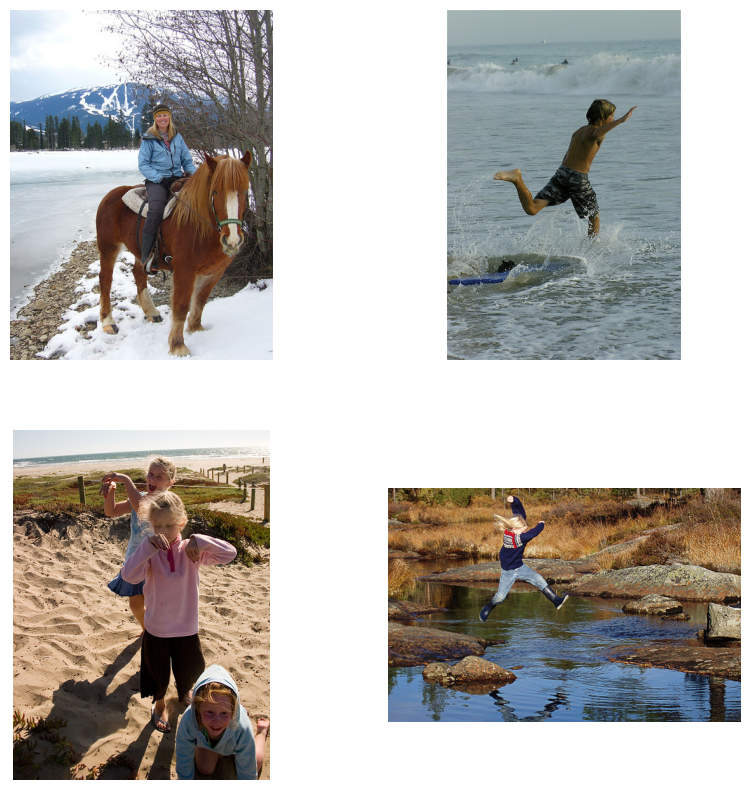

In [80]:
find_match(model, image_embeddings, "A person in an orange helmet climbs up a sheer cliff face", valid_df["image"].values)

In [ ]:
find_match(model, image_embeddings, "A woman in a blue jacket rides a brown pony near water", valid_df["image"].values)

Ну тут только в 1 фразе про собак есть какое-то совпадение. Странно, что женщину, про которую я спрашиваю в 3 фразе, он выдает в ответ на мужчину (2 фразу)

In [101]:
_, valid_df = make_train_valid_dfs()
image_embeddings = get_image_embeddings(valid_df, model_exp1)

Getting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
find_match(model_exp1, image_embeddings, "Two small dogs are chasing a ball", valid_df["image"].values)

In [ ]:
find_match(model_exp1, image_embeddings, "A person in an orange helmet climbs up a sheer cliff face", valid_df["image"].values)

In [ ]:
find_match(model_exp1, image_embeddings, "A woman in a blue jacket rides a brown pony near water", valid_df["image"].values)

Здесь можно сказать, что собаки почетче немного, во 2 фразе тоже нашел хотя бы мужчину на фоне скал. 3 фраза мимо, как и в бейзлайне

In [90]:
_, valid_df = make_train_valid_dfs()
image_embeddings = get_image_embeddings(valid_df, model_exp2)

Getting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
find_match(model_exp2, image_embeddings, "Two small dogs are chasing a ball", valid_df["image"].values)

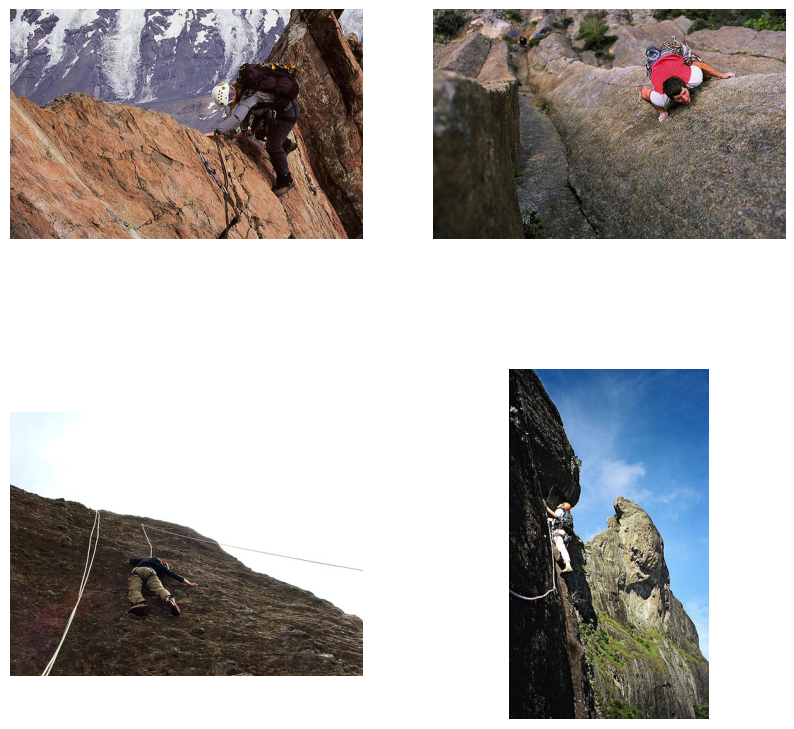

In [93]:
find_match(model_exp2, image_embeddings, "A person in an orange helmet climbs up a sheer cliff face", valid_df["image"].values)

In [ ]:
find_match(model_exp2, image_embeddings, "A woman in a blue jacket rides a brown pony near water", valid_df["image"].values)

Эта модель (которая должна быть лучшей) хорошо в целом отрабатывает на собаках - везде их хотя бы две, и они на 2/4 картинках куда-то бегут. На 2 фразе тоже хорошо: везде мужчины лезут на скалы, а посл фото вообще как будто та, что и должны быть. На 3 фразу тоже неплохо: на всех фото женщины, а на 2/4 они на лошадях (3 фото почти то, что нужно, но не хватает воды рядом)

In [94]:
_, valid_df = make_train_valid_dfs()
image_embeddings = get_image_embeddings(valid_df, model_exp3)

Getting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
find_match(model_exp3, image_embeddings, "Two small dogs are chasing a ball", valid_df["image"].values)

In [ ]:
find_match(model_exp3, image_embeddings, "A person in an orange helmet climbs up a sheer cliff face", valid_df["image"].values)

In [ ]:
find_match(model_exp3, image_embeddings, "A woman in a blue jacket rides a brown pony near water", valid_df["image"].values)

Здесь собаки (1 фраза) немного хуже, чем на предыдущей модели, тк есть фото с только 1 собакой. На 2 фразе тоже немного похуже, чем на модели 2 эксперимента (но все равно хорошо, хоть и не нашел в оранж шлеме, но на всех фото мужчины лезут на скалы/в горы). На 3 фразе справилась даже лучше, потому что нашла женщину в голубой куртку на лошади, которая именно около воды.

## Опишите свои результаты.

Описал выше. В целом можно сказать, что 2 модель is the best (3 модель немного ей уступает)

Можно сказать, что температура походу самый важный гиперпараметр в CLIP - дала улучшение как по метрикам, так и на валидации в кач-ве предиктов. Обучаемая температура, возможно, и могла бы дать лучшие результаты, если бы не произошел overfitting (нужна больше выборка)